In [2]:
from pathlib import Path
import sys

# ensure the repository root (which contains kxor_code/) is on sys.path
repo_root = Path.cwd()
if not (repo_root / "kxor_code").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

from kxor_code.problem_set_generation.kxor_instance import KXORInstance
from kxor_code.problem_set_generation.kikuchi_matrix_generator import compute_kikuchi_matrix, find_eigenvalues_and_vectors

path = "/home/mathiasyap/Code/university/quantumkxor/QuarticSpeedupK-XOR/data/temp/kxor_instance_n40_k4_m295_rho0.2.npz" 
problem_instance= KXORInstance.load(path)
kikuchi_matrix = compute_kikuchi_matrix(problem_instance, ell=2)
if not kikuchi_matrix.shape:
    raise ValueError("Kikuchi matrix is empty.")
eigenvalues, eigenvectors = find_eigenvalues_and_vectors(kikuchi_matrix, num_eigenvalues=kikuchi_matrix.shape[0]-1)

In [3]:
print(max(eigenvalues))

3.5446492543190526


In [ ]:
# create a new instance with the same parameters but rho = 0
import numpy as np
import pandas as pd
from kxor_code.problem_set_generation.planted_noisy_kxor_generator import PlantedNoisyKXORGenerator

df = pd.DataFrame(columns=["n", "k", "m", "rho", "eigenvalues_planted", "eigenvalues_random", "ell"])
k = 4
n = 100
m = int(.25 * np.log(n) * n) + 1
print(f"n={n}, k={k}, m={m}")
rng = np.random.default_rng(seed=42)
ells = [30] 
""" np.linspace(3,35,5,dtype=int) """
for ell in ells:
    for i in range(10):
        generator = PlantedNoisyKXORGenerator(n = n,
                                              k = k,
                                              rng = rng)
        random_instance = (generator.sample_random(m = m))
        planted_instance = (generator.sample_planted(m = m, rho = .25))
        random_kikuchi = compute_kikuchi_matrix(random_instance, ell=2)
        planted_kikuchi = compute_kikuchi_matrix(planted_instance, ell=2)

        if not random_kikuchi.shape:
            raise ValueError("Kikuchi matrix is empty.")
        if not planted_kikuchi.shape:
            raise ValueError("Kikuchi matrix is empty.")

        eigenvalues_random, _ = find_eigenvalues_and_vectors(
            random_kikuchi, num_eigenvalues=random_kikuchi.shape[0]-1 
        )
        eigenvalues_planted, _ = find_eigenvalues_and_vectors(
            planted_kikuchi, num_eigenvalues=planted_kikuchi.shape[0]-1 
        )
        df = pd.concat(
            [
                df,
                pd.DataFrame(
                    {
                        "n": [n],
                        "k": [k],
                        "m": [m],
                        "rho": [0.0],
                        "eigenvalues_planted": [eigenvalues_planted],
                        "eigenvalues_random": [eigenvalues_random],
                        "ell": [ell],
                    }
                ),
            ],
            ignore_index=True,
        )
        

n=100, k=4, m=116


In [1]:
path = "data/temp/kxor_instance_n20_k6_m60_rho0.2.npz"
instance = KXORInstance.load(path)

NameError: name 'KXORInstance' is not defined

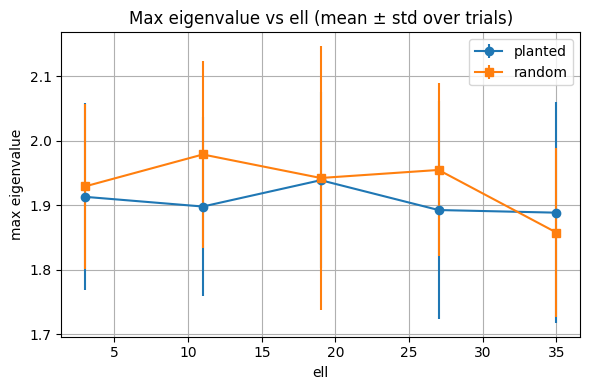

In [46]:
import matplotlib.pyplot as plt

# compute max eigenvalue per row
df["max_planted"] = df["eigenvalues_planted"].apply(lambda ev: np.max(ev) if len(ev) else np.nan)
df["max_random"] = df["eigenvalues_random"].apply(lambda ev: np.max(ev) if len(ev) else np.nan)

# aggregate (mean and std) by ell
agg = df.groupby("ell").agg(
    mean_planted=("max_planted", "mean"),
    std_planted=("max_planted", "std"),
    mean_random=("max_random", "mean"),
    std_random=("max_random", "std"),
).reset_index()

# plot
plt.figure(figsize=(6,4))
plt.errorbar(agg["ell"], agg["mean_planted"], yerr=agg["std_planted"], label="planted", marker="o")
plt.errorbar(agg["ell"], agg["mean_random"], yerr=agg["std_random"], label="random", marker="s")
plt.xlabel("ell")
plt.ylabel("max eigenvalue")
plt.title("Max eigenvalue vs ell (mean ± std over trials)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()